# Radius of gyration exploration
[_definition_](https://en.wikipedia.org/wiki/Radius_of_gyration)

In [1]:
from datetime import datetime

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import seaborn as sns
import shapely

from wpp import data, db
from wpp.utils import project_root

In [2]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

con = db.connect()
state_fips = '12'

In [ ]:
heatwave_date = datetime.fromisoformat("2025-07-27")

In [3]:
pois = con.sql(f"""
    WITH wpp AS (
        SELECT ID_STORE, SUM(VISITOR_COUNTS) AS VISITOR_COUNTS
        FROM wpp_{state_fips}
        GROUP BY 1
    )
    SELECT pois.*, wpp.VISITOR_COUNTS
    FROM pois_{state_fips} pois
    JOIN wpp ON pois.ID_STORE = wpp.ID_STORE
""").pl().with_columns(
    pl.col("VISITOR_COUNTS")
        .qcut(10, labels=[str(i) for i in range(1, 11)])
        .cast(pl.Utf8).cast(pl.Int64).alias("VISITOR_DECILE")
)
pois

<sys>:0: UserWarning: Extension type 'geoarrow.wkb' is not registered; loading as its storage type.

To avoid this warning, register the extension type or set environment variable 'POLARS_UNKNOWN_EXTENSION_TYPE_BEHAVIOR' to 'load_as_storage' or 'load_as_extension'.

In Polars 2.0, the default behavior will change to 'load_as_extension'.


ID_STORE,BRAND,LOCATION_NAME,STREET_ADDRESS,POI_CBG,CITY,REGION,ISO_COUNTRY_CODE,TOP_CATEGORY,SUB_CATEGORY,OPEN_DATE,CLOSE_DATE,LONGITUDE,LATITUDE,GEOM,VISITOR_COUNTS,VISITOR_DECILE
str,str,str,str,str,str,str,str,str,str,date,date,f64,f64,binary,"decimal[38,0]",i64
"""7111218""","""MetroPCS""","""MetroPCS Wireless""","""3186 West 76Th Street""","""120860132022""","""Hialeah""","""FL""","""US""","""Wired and Wireless Telecommuni…","""Wireless Telecommunications Ca…",1970-01-01,2038-01-01,-80.347536,25.891137,"b""\x01\x01\x00\x00\x00\xb1\x8b\xa2\x07>\x16T\xc0\x9c\xc5\x8b\x85!\xe49@""",55562,7
"""7929329""","""Supermarkets and Other Grocery…","""Supermarkets and Other Grocery…","""601 Sw 33Rd Ave""","""120830025071""","""Ocala""","""FL""","""US""","""Grocery Stores ""","""Supermarkets and Other Grocery…",1970-01-01,2038-01-01,-82.209442,29.15642,"b""\x01\x01\x00\x00\x00\xf5y\xd6\x7fg\x8dT\xc0er\xc5\x20\x0b(=@""",1531,2
"""10072690""","""Painting and Wall Covering Con…","""Painting and Wall Covering Con…","""8428 Crystal Harbour Dr""","""120570116132""","""Tampa""","""FL""","""US""","""Building Finishing Contractors""","""Painting and Wall Covering Con…",1970-01-01,2038-01-01,-82.576492,28.000773,"b""\x01\x01\x00\x00\x00a\xda\xdc=\xe5\xa4T\xc0\xf2\xb9n\xa52\x00<@""",12917,4
"""8905036""","""Full-Service Restaurants""","""Full-Service Restaurants""","""14205 Furman Ave""","""120950165091""","""Orlando""","""FL""","""US""","""Restaurants and Other Eating P…","""Full-Service Restaurants """,1970-01-01,2038-01-01,-81.174316,28.59059,"b""\x01\x01\x00\x00\x00\x03J\xf9\xff'KT\xc0j\xdc\x9b\xdf0\x97<@""",5692,3
"""10162073""","""Retail Bakeries""","""Retail Bakeries""","""535 W New England Ave""","""120950159012""","""Winter Park""","""FL""","""US""","""Bakeries and Tortilla Manufact…","""Retail Bakeries """,1970-01-01,2038-01-01,-81.356453,28.59598,"b""\x01\x01\x00\x00\x00\x1e\x04\xd3\x1f\xd0VT\xc0t\x94(\x20\x92\x98<@""",25028,6
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""7937827""","""All Other General Merchandise …","""All Other General Merchandise …","""3152 Little Rd""","""121010315081""","""Trinity""","""FL""","""US""","""General Merchandise Stores, in…","""All Other General Merchandise …",1970-01-01,2038-01-01,-82.665962,28.20381,"b""\x01\x01\x00\x00\x00\xd2W\xeb\x1f\x9f\xaaT\xc0\x8a\x1b\\xdf,4<@""",46257,7
"""9979458""","""Painting and Wall Covering Con…","""Painting and Wall Covering Con…","""7536 Cutlass Ave""","""120860039173""","""North Bay Village""","""FL""","""US""","""Building Finishing Contractors""","""Painting and Wall Covering Con…",1970-01-01,2038-01-01,-80.151581,25.845551,"b""\x01\x01\x00\x00\x00\xe6\xac\xf4\x7f\xb3\x09T\xc0\xd0\x9d`\xffu\xd89@""",1372,2
"""7356008""","""Navy Federal""","""Navy Federal Credit Union""","""9583 Regency Square Blvd""","""120310146041""","""Jacksonville""","""FL""","""US""","""Depository Credit Intermediati…","""Commercial Banking """,1970-01-01,2038-01-01,-81.548241,30.326806,"b""\x01\x01\x00\x00\x00\xe3Tka\x16cT\xc0\xc7\x9e=\x97\xa9S>@""",138375,9


In [4]:
bg_df = con.sql(f"SELECT * FROM bg_{state_fips}").df()
bg_df["geom"] = bg_df["geom"].apply(bytes)
gdf = gpd.GeoDataFrame(
    bg_df, 
    geometry=gpd.GeoSeries.from_wkb(bg_df["geom"]), 
    crs="EPSG:4326"
)

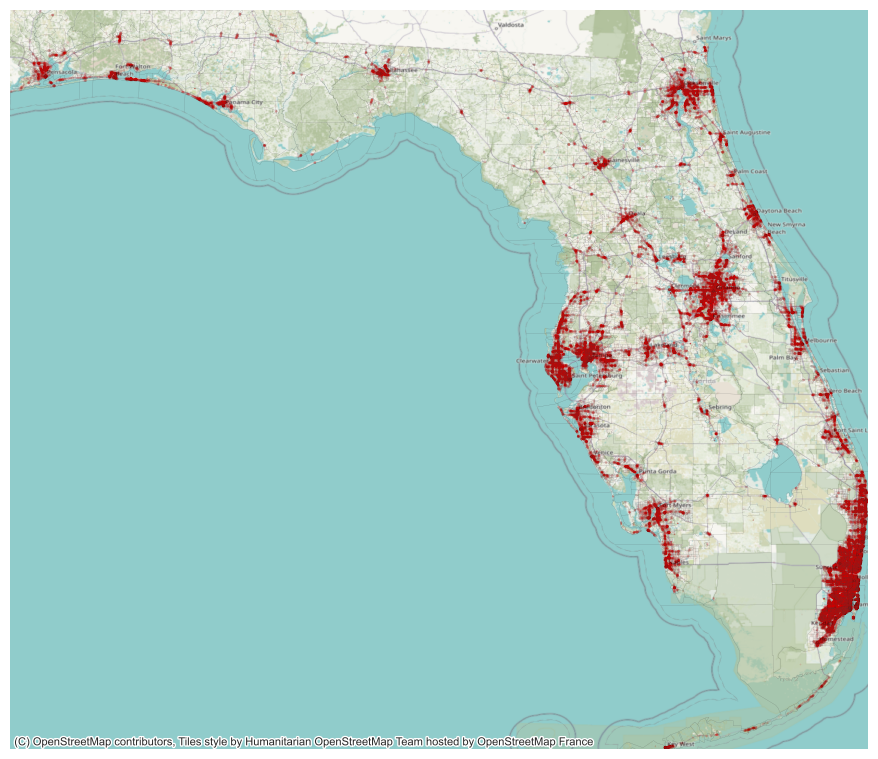

In [5]:
fig_scale = 2
fig, ax = plt.subplots(figsize=(6.4*fig_scale, 4.8*fig_scale))
ax = sns.scatterplot(
    pois, x="LONGITUDE", y="LATITUDE",
    color="#c00", size="VISITOR_DECILE", sizes=(.1, 5),
    alpha=.01, ax=ax, legend=False
)
gdf.boundary.plot(ax=ax, color="#444", linewidth=0.1, alpha=.4)
ax.set_xlim(pois["LONGITUDE"].min(), pois["LONGITUDE"].max())
ax.set_ylim(pois["LATITUDE"].min(), pois["LATITUDE"].max())
cx.add_basemap(ax, crs="EPSG:4326", zoom=8)
ax.set_axis_off()
ax.set_aspect("equal")

## Visits per day

In [20]:
visits_by_date = con.sql(f"""
    WITH x AS (
        SELECT 
            DATE_RANGE_START, 
            from_json(VISITS_BY_DAY, '["INTEGER"]')::INTEGER[7] AS VISITS_BY_DAY
        FROM wpp_{state_fips}
        WHERE VISITS_BY_DAY IS NOT NULL
          AND DATE_RANGE_START BETWEEN '2025-05-01' AND '2025-08-31'
    ), y AS (
        SELECT
            DATE_RANGE_START::DATE AS DATE,
            unnest(VISITS_BY_DAY) AS VISITS,
            generate_subscripts(VISITS_BY_DAY, 1) AS DAY
        FROM x
    )
    SELECT 
        (DATE + INTERVAL (DAY - 1) DAY)::DATE AS DATE,
        SUM(VISITS) AS VISITS
    FROM y
    GROUP BY 1
    ORDER BY 1
""").pl().with_columns(
    pl.col("VISITS").rolling_mean(window_size=7).alias("VISITS_ROLLING")
)

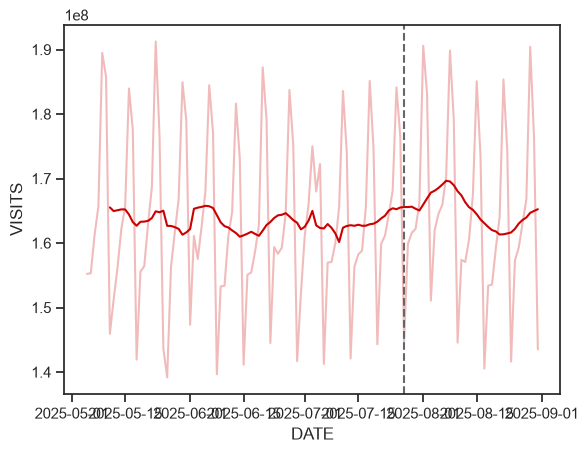

In [28]:
ax = sns.lineplot(
    visits_by_date,
    x="DATE",
    y="VISITS",
    color="#c004",
    legend=False
)
sns.lineplot(
    visits_by_date,
    x="DATE",
    y="VISITS_ROLLING",
    color="#c00",
    legend=False,
    ax=ax
)
ax.axvline(heatwave_date, color="#666", linestyle="--")

## Average distance traveled from home block group

In [6]:
bg_visits = con.sql(f"""
    WITH bg AS (
        SELECT GEOID, COUNTYFP, ST_Centroid(geom) as centroid
        FROM bg_{state_fips}
    ), bg_visits AS (
        SELECT 
            HOME_CBG, POI_CBG,
            DATE_RANGE_START, DATE_RANGE_END,
            SUM(VISITOR_COUNT) AS VISITOR_COUNT 
        FROM bg_poi_visits_{state_fips} 
        GROUP BY 1, 2, 3, 4
    )
    SELECT 
        bgv.*,
        bgh.centroid AS HOME_CBG_CENTROID,
        bgp.centroid AS POI_CBG_CENTROID,
        ST_Distance_Sphere(bgh.centroid, bgp.centroid) AS DIST_METERS,
        bgh.COUNTYFP AS HOME_COUNTY,
        bgp.COUNTYFP AS POI_COUNTY,
    FROM bg_visits bgv
    JOIN bg bgh ON bgv.HOME_CBG = bgh.GEOID
    JOIN bg bgp ON bgv.POI_CBG = bgp.GEOID
""").pl()
bg_visits

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

HOME_CBG,POI_CBG,DATE_RANGE_START,DATE_RANGE_END,VISITOR_COUNT,HOME_CBG_CENTROID,POI_CBG_CENTROID,DIST_METERS,HOME_COUNTY,POI_COUNTY
str,str,datetime[μs],datetime[μs],"decimal[38,0]",binary,binary,f64,str,str
"""120310137233""","""120310135042""",2025-11-17 00:00:00,2025-11-23 00:00:00,6437,"b""\x01\x01\x00\x00\x00\xac\x8d\x1c\xfd\xd5uT\xc0K\xb2\xfb\xa4M4>@""","b""\x01\x01\x00\x00\x00\xea\xe4D(nrT\xc0<\x9cW\xb7h>>@""",5949.858309,"""031""","""031"""
"""120310106011""","""120310135042""",2025-11-17 00:00:00,2025-11-23 00:00:00,738,"b""\x01\x01\x00\x00\x00\xe8\x1b\xd6\xe0\x9asT\xc0\xc3\xcb\x1f\x0a\xd4_>@""","b""\x01\x01\x00\x00\x00\xea\xe4D(nrT\xc0<\x9cW\xb7h>>@""",2907.716225,"""031""","""031"""
"""120310173002""","""120310135042""",2025-11-17 00:00:00,2025-11-23 00:00:00,901,"b""\x01\x01\x00\x00\x00\xc1""\xdd\xf8\xb7yT\xc0\x19\x0d\xcaT\xc9?>@""","b""\x01\x01\x00\x00\x00\xea\xe4D(nrT\xc0<\x9cW\xb7h>>@""",12663.195902,"""031""","""031"""
"""121030250112""","""121030245052""",2025-11-17 00:00:00,2025-11-23 00:00:00,780,"b""\x01\x01\x00\x00\x007\x84[\x00B\xb0T\xc0#8\xac2'\xe1;@""","b""\x01\x01\x00\x00\x00\xeb\xa9\x80\xc0\xc3\xadT\xc0\xdf1\x98+c\xdf;@""",4332.75687,"""103""","""103"""
"""120860155022""","""120860037061""",2025-11-17 00:00:00,2025-11-23 00:00:00,388,"b""\x01\x01\x00\x00\x00\x93\x8fK\xa3S\x19T\xc0n:ZO\xbb\xbb9@""","b""\x01\x01\x00\x00\x00*r{Fp\x0cT\xc0W\xa6_\x8c\x12\xc79@""",22407.502875,"""086""","""086"""
…,…,…,…,…,…,…,…,…,…
"""120110106122""","""120970409041""",2025-05-19 00:00:00,2025-05-25 00:00:00,13,"b""\x01\x01\x00\x00\x00k/;I\x84\x12T\xc0\xb0\xcd\xc9.\xacJ:@""","b""\x01\x01\x00\x00\x00\x0ah\xe6&\x8e]T\xc0\xf0\x8c\x96""}T<@""",135217.227868,"""011""","""097"""
"""120860069011""","""120860038015""",2025-05-26 00:00:00,2025-06-01 00:00:00,49,"b""\x01\x01\x00\x00\x00\xedYf\x00\xfe\x0eT\xc0\xbdx\x0ay\x88\xbe9@""","b""\x01\x01\x00\x00\x00\xccH\xfa\xd2p\x08T\xc0%f_\xab\xc2\xe39@""",11711.781403,"""086""","""086"""
"""120110203121""","""120860038015""",2025-05-26 00:00:00,2025-06-01 00:00:00,25,"b""\x01\x01\x00\x00\x00c\xf8\x9e\xa6\xb5\x12T\xc0\xbb\xf0\xd5@\xc1C:@""","b""\x01\x01\x00\x00\x00\xccH\xfa\xd2p\x08T\xc0%f_\xab\xc2\xe39@""",19197.745969,"""011""","""086"""


In [7]:
agg = bg_visits.group_by("DATE_RANGE_START", "HOME_CBG").agg(
    pl.col("VISITOR_COUNT").sum(),
    ((pl.col("VISITOR_COUNT") * pl.col("DIST_METERS")).sum() / pl.col("VISITOR_COUNT").sum()).alias("DIST_METERS")
)
agg.head()

DATE_RANGE_START,HOME_CBG,VISITOR_COUNT,DIST_METERS
datetime[μs],str,"decimal[38,0]",f64
2025-04-07 00:00:00,"""120570110051""",119843,19190.392687
2025-12-01 00:00:00,"""120570049022""",24457,4489.646813
2025-08-25 00:00:00,"""120310167241""",64875,7083.853464
2025-08-18 00:00:00,"""121010304051""",20505,5233.108411
2025-10-27 00:00:00,"""121030252101""",56089,19579.196445


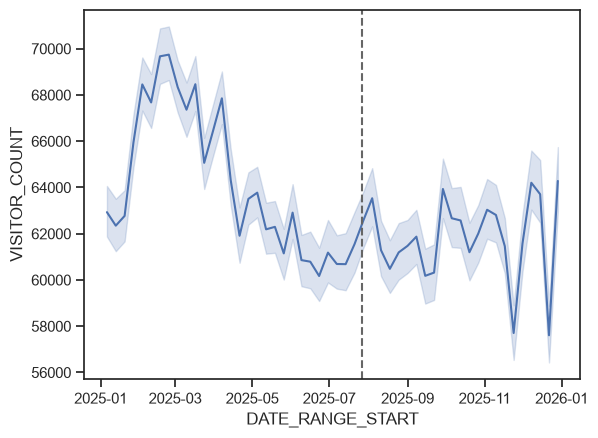

In [8]:
ax = sns.lineplot(
    agg,
    x="DATE_RANGE_START",
    y="VISITOR_COUNT",
    legend=False
)
ax.axvline(heatwave_date, color="#666", linestyle="--")

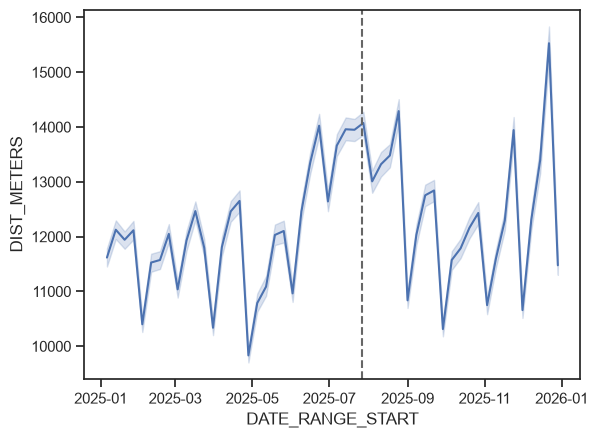

In [9]:
ax = sns.lineplot(
    agg,
    x="DATE_RANGE_START",
    y="DIST_METERS",
    legend=False
)
ax.axvline(heatwave_date, color="#666", linestyle="--")

In [10]:
agg = bg_visits.group_by("DATE_RANGE_START").agg(
    pl.col("VISITOR_COUNT").sum(),
    ((pl.col("VISITOR_COUNT") * pl.col("DIST_METERS")).sum() / pl.col("VISITOR_COUNT").sum()).alias("DIST_METERS")
)
agg.head()

DATE_RANGE_START,VISITOR_COUNT,DIST_METERS
datetime[μs],"decimal[38,0]",f64
2025-12-08 00:00:00,856236545,12803.565478
2025-04-14 00:00:00,857598829,12892.381926
2025-04-21 00:00:00,825480561,13076.644315
2025-12-01 00:00:00,821152879,10990.473215
2025-08-11 00:00:00,817338697,13718.743887


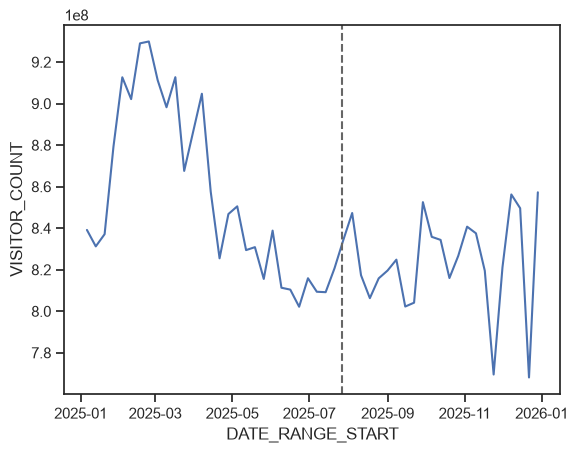

In [11]:
ax = sns.lineplot(
    agg,
    x="DATE_RANGE_START",
    y="VISITOR_COUNT",
    legend=False
)
ax.axvline(heatwave_date, color="#666", linestyle="--")

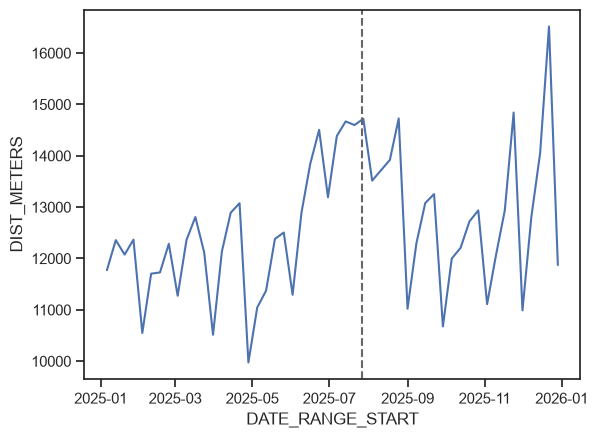

In [12]:
ax = sns.lineplot(
    agg,
    x="DATE_RANGE_START",
    y="DIST_METERS",
    legend=False
)
ax.axvline(heatwave_date, color="#666", linestyle="--")